In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Загружаем датасет Netflix
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

print("=" * 50)
print("NETFLIX MOVIES AND TV SHOWS - ПЕРВЫЙ АНАЛИЗ")
print("=" * 50)

# 1. Размер датасета
print(f"\n📊 Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

# 2. Первые строки
print("\n📺 Первые 5 строк:")
print(df.head())

# 3. Информация о столбцах
print("\n📋 Информация о датасете:")
print(df.info())

# 4. Пропуски
print("\n⚠️ Пропуски в данных:")
print(df.isnull().sum())

# 5. Базовая статистика
print("\n📈 Статистика:")
print(df.describe())

NETFLIX MOVIES AND TV SHOWS - ПЕРВЫЙ АНАЛИЗ

📊 Размер датасета: 8807 строк, 12 столбцов

📺 Первые 5 строк:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные (используйте ваш рабочий путь)
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

print("=" * 60)
print("NETFLIX MOVIES AND TV SHOWS - АНАЛИЗ")
print("=" * 60)

# 1. ОБЩАЯ ИНФОРМАЦИЯ
print("\n📊 ОБЩАЯ ИНФОРМАЦИЯ")
print(f"Всего записей: {len(df)}")
print(f"Всего столбцов: {len(df.columns)}")
print(f"\nСтолбцы: {list(df.columns)}")

# 2. ФИЛЬМЫ vs СЕРИАЛЫ
print("\n🎬 ФИЛЬМЫ vs СЕРИАЛЫ")
type_counts = df['type'].value_counts()
print(type_counts)
print(f"\nПроцент фильмов: {type_counts['Movie']/len(df)*100:.1f}%")
print(f"Процент сериалов: {type_counts['TV Show']/len(df)*100:.1f}%")

# 3. РЕЙТИНГИ
print("\n⭐ РЕЙТИНГИ КОНТЕНТА")
rating_counts = df['rating'].value_counts()
print(rating_counts)

# 4. ЖАНРЫ (TOP 10)
print("\n🎭 ТОП 10 ЖАНРОВ")
# Жанры разделены запятыми, нужно их разделить
all_genres = df['listed_in'].str.split(', ').explode()
print(all_genres.value_counts().head(10))

# 5. СТРАНЫ (TOP 10)
print("\n🌍 ТОП 10 СТРАН")
all_countries = df['country'].str.split(', ').explode()
print(all_countries.value_counts().head(10))

# 6. ГОДЫ ДОБАВЛЕНИЯ
print("\n📅 ДОБАВЛЕННЫЙ КОНТЕНТ ПО ГОДАМ")
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
yearly = df['release_year'].value_counts().sort_index()
print(yearly.tail(10))

# 7. ПРОПУСКИ
print("\n⚠️ ПРОПУЩЕННЫЕ ДАННЫЕ")
print(df.isnull().sum())

NETFLIX MOVIES AND TV SHOWS - АНАЛИЗ

📊 ОБЩАЯ ИНФОРМАЦИЯ
Всего записей: 8807
Всего столбцов: 12

Столбцы: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

🎬 ФИЛЬМЫ vs СЕРИАЛЫ
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Процент фильмов: 69.6%
Процент сериалов: 30.4%

⭐ РЕЙТИНГИ КОНТЕНТА
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

🎭 ТОП 10 ЖАНРОВ
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies   

In [16]:
# Смотрим странные рейтинги
print("Странные значения в rating:")
print(df[df['rating'].str.contains('min', na=False)][['title', 'rating', 'duration']].head(10))

# Проверяем уникальные рейтинги
print("\nВсе уникальные рейтинги:")
print(df['rating'].unique())

# Удаляем строки с невалидными рейтингами
df_clean = df[~df['rating'].str.contains('min', na=False)].copy()

print(f"До очистки: {len(df)} строк")
print(f"После очистки: {len(df_clean)} строк")
print(f"Удалено: {len(df) - len(df_clean)} строк с ошибками")

# Проверяем рейтинги заново
print("\n✅ Рейтинги после очистки:")
print(df_clean['rating'].value_counts())

Странные значения в rating:
                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN

Все уникальные рейтинги:
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']
До очистки: 8807 строк
После очистки: 8804 строк
Удалено: 3 строк с ошибками

✅ Рейтинги после очистки:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [28]:
# Используем чистые данные (df_clean)
print("=" * 60)
print("NETFLIX - ФИНАЛЬНЫЙ АНАЛИЗ (ЧИСТЫЕ ДАННЫЕ)")
print("=" * 60)

print(f"\n📊 Размер датасета: {len(df_clean)} записей")

# 1. ФИЛЬМЫ vs СЕРИАЛЫ
print("\n🎬 ФИЛЬМЫ vs СЕРИАЛЫ")
type_counts = df_clean['type'].value_counts()
print(type_counts)
print(f"Фильмы: {type_counts['Movie']/len(df_clean)*100:.1f}%")
print(f"Сериалы: {type_counts['TV Show']/len(df_clean)*100:.1f}%")

# 2. РЕЙТИНГИ (уже чистые!)
print("\n⭐ РЕЙТИНГИ КОНТЕНТА")
rating_top = df_clean['rating'].value_counts()
print(rating_top)

# 3. ЖАНРЫ
print("\n🎭 ТОП 10 ЖАНРОВ")
all_genres = df_clean['listed_in'].str.split(', ').explode()
print(all_genres.value_counts().head(10))

# 4. СТРАНЫ
print("\n🌍 ТОП 10 СТРАН")
all_countries = df_clean['country'].str.split(', ').explode()
print(all_countries.value_counts().head(10))

# 5. ИНТЕРЕСНЫЕ ФАКТЫ
print("\n💡 ИНТЕРЕСНЫЕ ФАКТЫ")
print(f"Самый старый контент: {df_clean['release_year'].min()}")
print(f"Самый новый контент: {df_clean['release_year'].max()}")
print(f"Средний год выпуска: {df_clean['release_year'].mean():.0f}")
print(f"Пропуски в режиссёрах: {df_clean['director'].isnull().sum()} ({df_clean['director'].isnull().sum()/len(df_clean)*100:.1f}%)")

NETFLIX - ФИНАЛЬНЫЙ АНАЛИЗ (ЧИСТЫЕ ДАННЫЕ)

📊 Размер датасета: 8804 записей

🎬 ФИЛЬМЫ vs СЕРИАЛЫ
type
Movie      6128
TV Show    2676
Name: count, dtype: int64
Фильмы: 69.6%
Сериалы: 30.4%

⭐ РЕЙТИНГИ КОНТЕНТА
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

🎭 ТОП 10 ЖАНРОВ
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

🌍 ТОП 10 СТРАН
country
United States     3686
India             1046
United Kingdom     804
Canada             445
France             3

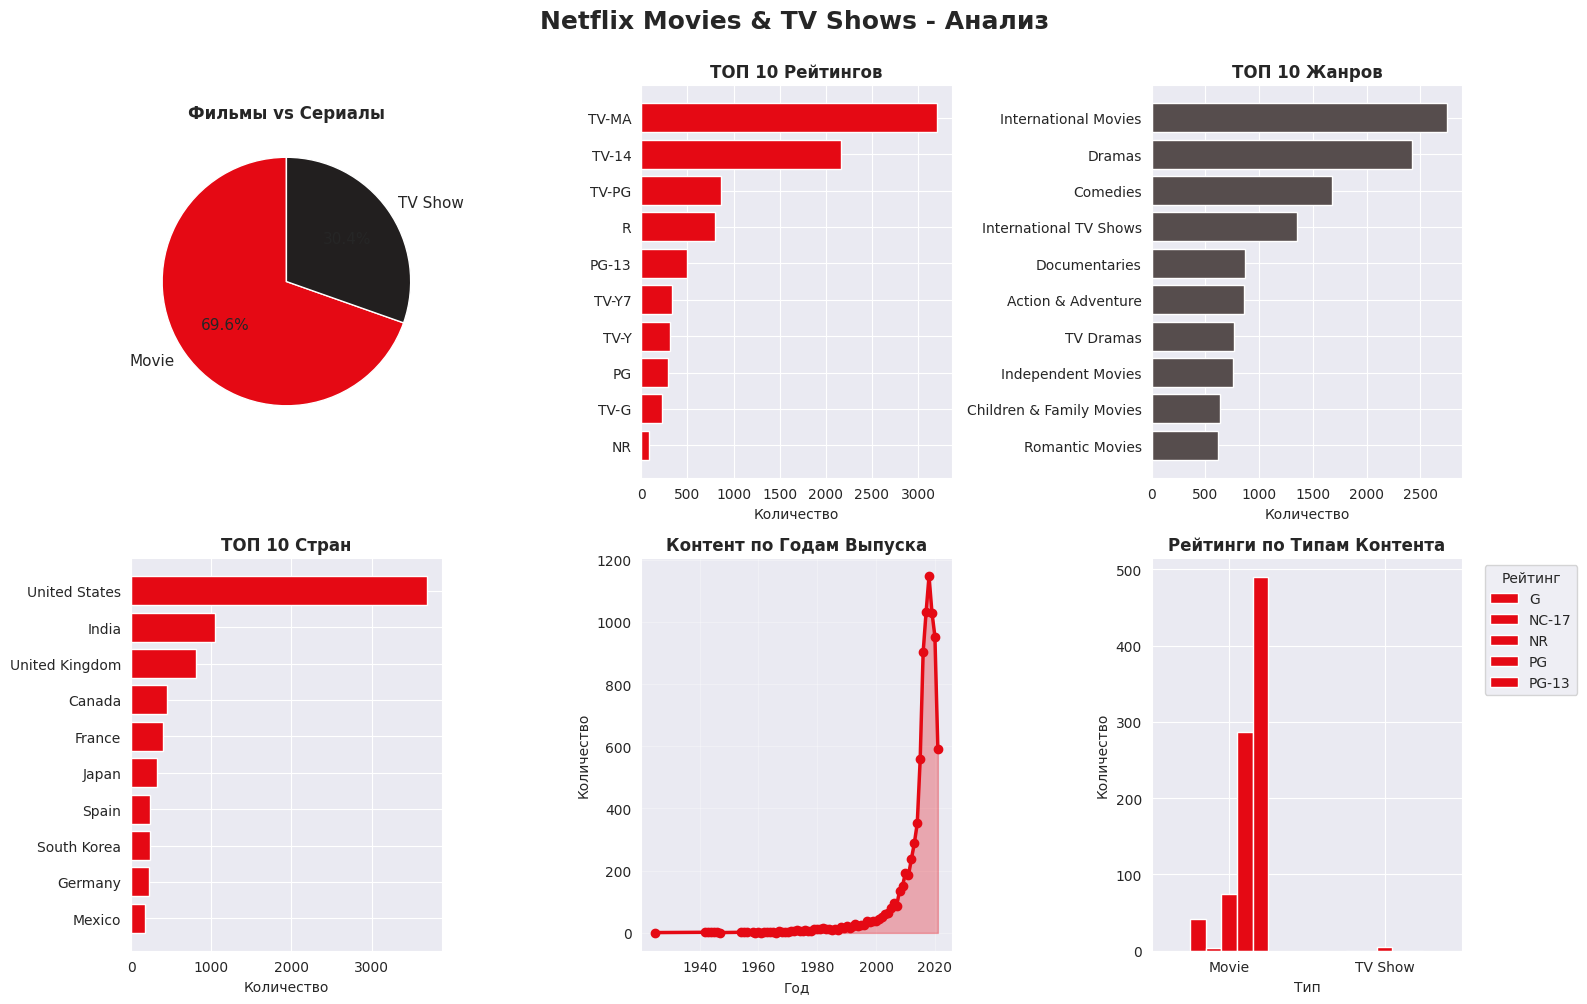

In [27]:
# Настраиваем стиль
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Создаём 2x3 сетку графиков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Netflix Movies & TV Shows - Анализ', fontsize=18, fontweight='bold', y=1.00)

# 1. Фильмы vs Сериалы (пай-чарт)
type_counts = df_clean['type'].value_counts()
colors = ['#E50914', '#221F1F']  # Netflix цвета
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0, 0].set_title('Фильмы vs Сериалы', fontsize=12, fontweight='bold')

# 2. Рейтинги (ТОП 10)
rating_top = df_clean['rating'].value_counts().head(10)
axes[0, 1].barh(rating_top.index, rating_top.values, color='#E50914')
axes[0, 1].set_title('ТОП 10 Рейтингов', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Количество')
axes[0, 1].invert_yaxis()

# 3. Жанры (ТОП 10)
all_genres = df_clean['listed_in'].str.split(', ').explode()
genre_top = all_genres.value_counts().head(10)
axes[0, 2].barh(genre_top.index, genre_top.values, color='#564D4D')
axes[0, 2].set_title('ТОП 10 Жанров', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Количество')
axes[0, 2].invert_yaxis()

# 4. Страны (ТОП 10)
all_countries = df['country'].str.split(', ').explode()
country_top = all_countries.value_counts().head(10)
axes[1, 0].barh(country_top.index, country_top.values, color='#E50914')
axes[1, 0].set_title('ТОП 10 Стран', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Количество')
axes[1, 0].invert_yaxis()

# 5. Контент по годам
yearly = df_clean['release_year'].value_counts().sort_index()
axes[1, 1].plot(yearly.index, yearly.values, marker='o', linewidth=2.5, 
                markersize=6, color='#E50914')
axes[1, 1].fill_between(yearly.index, yearly.values, alpha=0.3, color='#E50914')
axes[1, 1].set_title('Контент по Годам Выпуска', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].grid(True, alpha=0.3)

# 6. Тип контента по рейтингам
type_rating = pd.crosstab(df_clean['type'], df_clean['rating']).iloc[:, :5]
type_rating.plot(kind='bar', ax=axes[1, 2], color='#E50914')
axes[1, 2].set_title('Рейтинги по Типам Контента', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Тип')
axes[1, 2].set_ylabel('Количество')
axes[1, 2].legend(title='Рейтинг', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()